# Package Groupe 19

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_DBR
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode
from Package_Lab import LL_RT,PID_RT,IMC_TUNING,MARGIN

# LL_RT()

In [64]:
help(LL_RT)

Help on function LL_RT in module Package_Lab:

LL_RT(MV, Kp, Ts, T_LEAD, T_LAG, PV, PVInit=0)
    The function "LL_RT" needs to be included in a "for or while loop".

    :MV: input vector
    :Kp: process gain
    :T_LEAD: lead time constant [s]
    :T_LAG: lag time constant [s]
    :Ts: sampling period [s]
    :PV: output vector
    :PVInit: (optional: default value is 0)

    The function "LL_RT" appends a value to the output vector "PV".
    The appended value is obtained from a recurrent equation that depends on the discretisation method.



(0.0, 100.0)

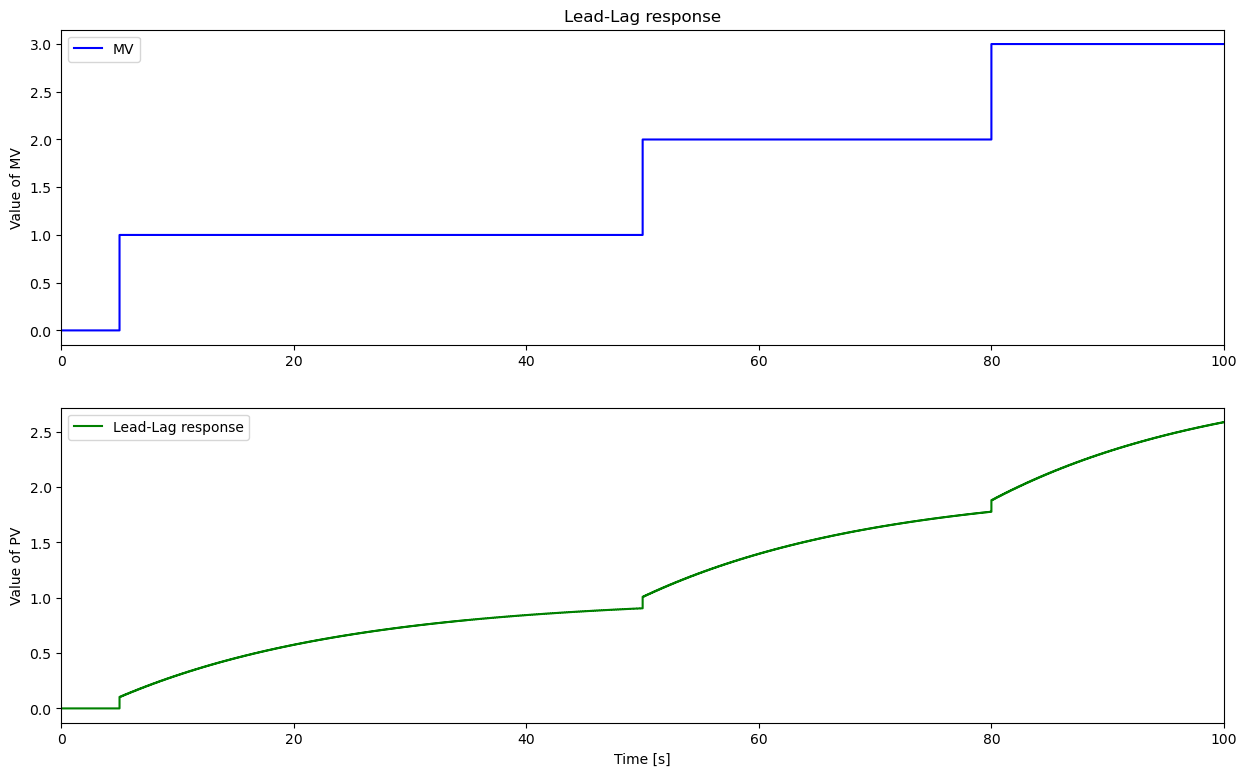

In [65]:
TSim = 100
Ts = 0.1
N = int(TSim/Ts) + 1

# Path for MV
MVPath = {0: 0, 5: 1, 50: 2, 80: 3, TSim: 3}

t = []
MV = []
PV = []

# Parameters
kp = 1
T_Lead = 2
T_Lag = 20


# MV is created from MVPath
for i in range(0,N):
    t.append(i*Ts)
    SelectPath_RT(MVPath,t,MV)
    LL_RT(MV,kp,Ts,T_Lead,T_Lag,PV,PVInit=0)
    

    
plt.figure(figsize = (15,9))

plt.subplot(2,1,1)
plt.step(t,MV,'b-',label='MV',where='post')
plt.ylabel('Value of MV')
plt.title('Lead-Lag response')
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.subplot(2,1,2)
plt.step(t,PV,'g-',label='Lead-Lag response',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')
plt.xlim([0, TSim])

# PID_RT()

In [66]:
help(PID_RT)

Help on function PID_RT in module Package_Lab:

PID_RT(
    SP,
    PV,
    Man,
    MVMan,
    MVFF,
    Kc,
    Ti,
    Td,
    alpha,
    Ts,
    MVMin,
    MVMax,
    MV,
    MVP,
    MVI,
    MVD,
    E,
    ManFF=False,
    PVInit=0,
    methode='EBD-EBD'
)
    The function "PID_RT" needs to be included in a "for or while loop".

    :SP: setpoint vector
    :PV: process variable vector
    :Man: manual mode vector
    :MVMan: manual value vector
    :MVFF: feedforward value vector
    :Kc: proportional gain
    :Ti: integral time
    :Td: derivative time
    :alpha: derivative filter coefficient
    :Ts: sampling period
    :MVMin: minimum manipulated variable
    :MVMax: maximum manipulated variable
    :MV: manipulated variable vector
    :MVP: proportional term vector
    :MVI: integral term vector
    :MVD: derivative term vector
    :E: error vector
    :ManFF: feedforward in manual mode flag
    :PVInit: initial process variable value
    :methode: method for discretizatio

(0.0, 250.0)

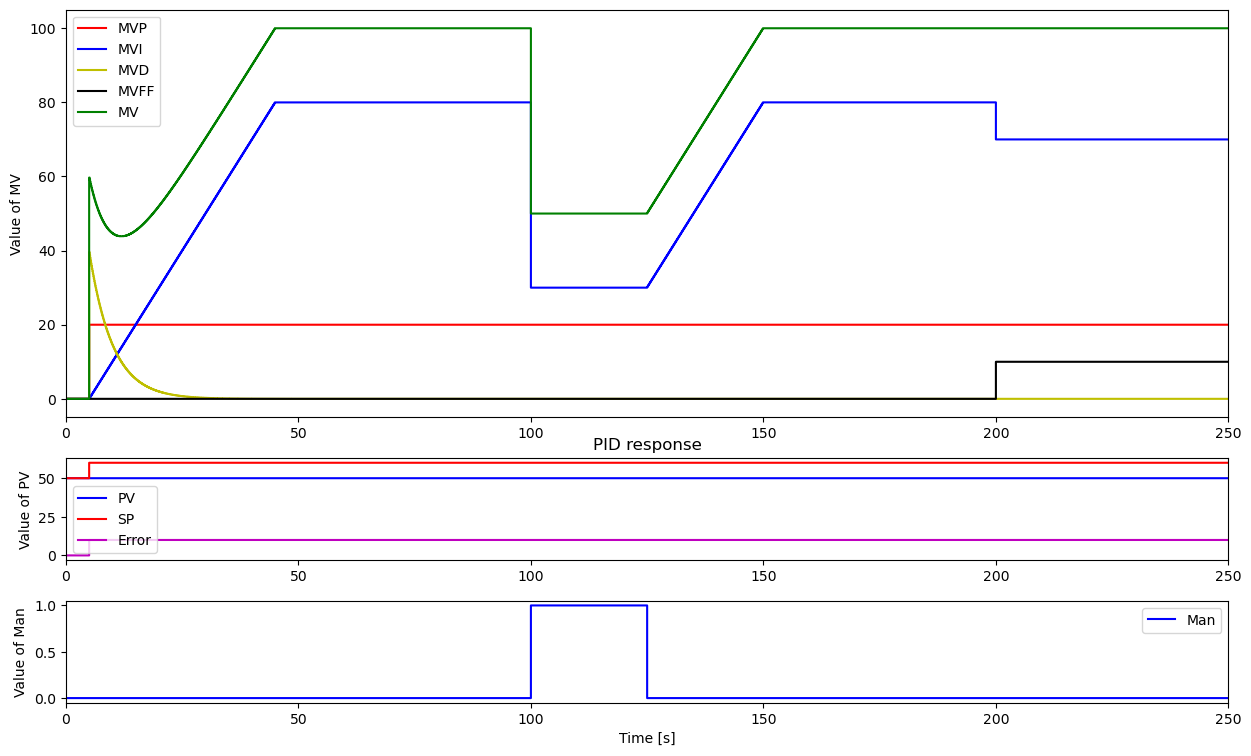

In [67]:
TSim = 250
Ts = 0.1
N = int(TSim/Ts) + 1

# Path
SPPath = {0: 50, 5: 60,TSim: 60}
PVPath = {0: 50, TSim: 50}
ManPath = {0: False, 100:True, 125:False, TSim:False}
MVManPath = {0: 0, 100: 50, TSim: 50}
MVFFPath= {0:0,200:10,TSim:10}

t = []
SP = []
MV = []
MVFF = []
MVMan = []
MVP = []
MVI = []
MVD = []
PV = []
E = []
Man = []

# Parameters
Kc = 2
Ti = 10
Td = 10
alpha = 0.5
MVMin = 0
MVMax = 100
ManFF = False

# MV is created from MVPath
for i in range(0,N):
    t.append(i*Ts)
    SelectPath_RT(SPPath,t,SP)
    SelectPath_RT(PVPath,t,PV)
    SelectPath_RT(ManPath,t,Man)
    SelectPath_RT(MVManPath,t,MVMan)
    SelectPath_RT(MVFFPath,t,MVFF)
    PID_RT(SP,PV,Man,MVMan,MVFF,Kc,Ti,Td,alpha,Ts,MVMin,MVMax,MV,MVP,MVI,MVD,E,ManFF,PVInit=50,methode='TRAP-TRAP')

fig, axs = plt.subplots(3, 1, figsize=(15,9),
                        gridspec_kw={'height_ratios': [4, 1, 1]})

axs[0].step(t, MVP, 'r-', label='MVP', where='post')
axs[0].step(t, MVI, 'b-', label='MVI', where='post')
axs[0].step(t, MVD, 'y-', label='MVD', where='post')
axs[0].step(t, MVFF, 'k-', label='MVFF', where='post')
axs[0].step(t, MV, 'g-', label='MV', where='post')
axs[0].set_ylabel('Value of MV')
axs[0].legend(loc='best')
axs[0].set_xlim([0, TSim])

axs[1].step(t, PV, 'b-', label='PV', where='post')
axs[1].step(t, SP, 'r-', label='SP', where='post')
axs[1].step(t, E, 'm-', label='Error', where='post')
axs[1].set_ylabel('Value of PV')
axs[1].set_title('PID response')
axs[1].legend(loc='best')
axs[1].set_xlim([0, TSim])

axs[2].step(t, Man, 'b-', label='Man', where='post')
axs[2].set_ylabel('Value of Man')
axs[2].set_xlabel('Time [s]')
axs[2].legend(loc='best')
axs[2].set_xlim([0, TSim])

# IMC_TUNING()

In [68]:
help(IMC_TUNING)

Help on function IMC_TUNING in module Package_Lab:

IMC_TUNING(Kp, gamma, T1, T2=0, theta=0)
    The function "IMC_TUNING" computes the PID parameters based on the IMC tuning rules.

    :Kp: process gain
    :gamma: constant aggressiveness
    :T1: first time constant
    :T2: second time constant (default is 0)
    :alpha: derivative filter coefficient (default is 0)

    If T2 is equal to 0, the process is considered as a first order system.
    If Alpha is equal to 0, the process is considered as a system without delay.

    :return: Kc, Ti, Td (PID parameters)



In [69]:
Kp = 10
gamma = 0.5
T1 = 130
T2 = 35
Theta = 14

Kc, Ti, Td = IMC_TUNING(Kp, gamma, T1, T2, Theta)

print(f'Kc: {Kc}, Ti: {Ti}, Td: {Td}')

Kc: 0.2088607594936709, Ti: 165, Td: 27.575757575757574


# MARGIN()

In [70]:
help(MARGIN)

Help on function MARGIN in module Package_Lab:

MARGIN(Ps, omega)
    The function "MARGIN" computes the gain margin and the phase margin of a system.
    :Ps: vector of the process sensitivity function evaluated at the frequencies in "omega"
    :omega: vector of frequencies at which the process sensitivity function is evaluated



Load Data

In [71]:
import json


EXPERIENCE_NAME = "experience_MV_01"

with open('Data/experiences.json', 'r') as f:
    db = json.load(f)

exp = next((e for e in db['experiences'] if e['namefile'] == EXPERIENCE_NAME), None)

if exp is None:
    raise ValueError(f"❌ Expérience '{EXPERIENCE_NAME}' introuvable dans le JSON.")

nameFile  = exp['datafile']
titleName = nameFile.split('.')[0]
data      = pd.read_csv('Data/' + nameFile)

Kp_OP_SOPDT    = exp['SOPDT_OPT']['Kp']
T1_OP_SOPDT    = exp['SOPDT_OPT']['T1']
T2_OP_SOPDT    = exp['SOPDT_OPT']['T2']
Theta_OP_SOPDT = exp['SOPDT_OPT']['Theta']

print(f"Kp_OP_SOPDT: {Kp_OP_SOPDT}, T1_OP_SOPDT: {T1_OP_SOPDT}, T2_OP_SOPDT: {T2_OP_SOPDT}, Theta_OP_SOPDT: {Theta_OP_SOPDT}")

Kp_OP_SOPDT: 0.5315977216868413, T1_OP_SOPDT: 143.20962826230692, T2_OP_SOPDT: 23.744697190626116, Theta_OP_SOPDT: 17.394912344235067


In [72]:
omega = np.logspace(-4, 1, 10000)

P_SOPDT_OPT = Process({})
P_SOPDT_OPT.parameters['Kp']    = Kp_OP_SOPDT
P_SOPDT_OPT.parameters['Tlag1'] = T1_OP_SOPDT
P_SOPDT_OPT.parameters['Tlag2'] = T2_OP_SOPDT
P_SOPDT_OPT.parameters['theta'] = Theta_OP_SOPDT

PS = Bode(P_SOPDT_OPT,omega,False)

Frequency at which the phase is -180 degrees: 0.04895183506376762 rad/s
Frequency at which the gain is 1: 0.0001 rad/s
Gain Margin (GM): 20.42504759260794, Phase Margin (PM): 178.94381301476628
Gain Margin (GM) in dB: 26.203261543191072 dB


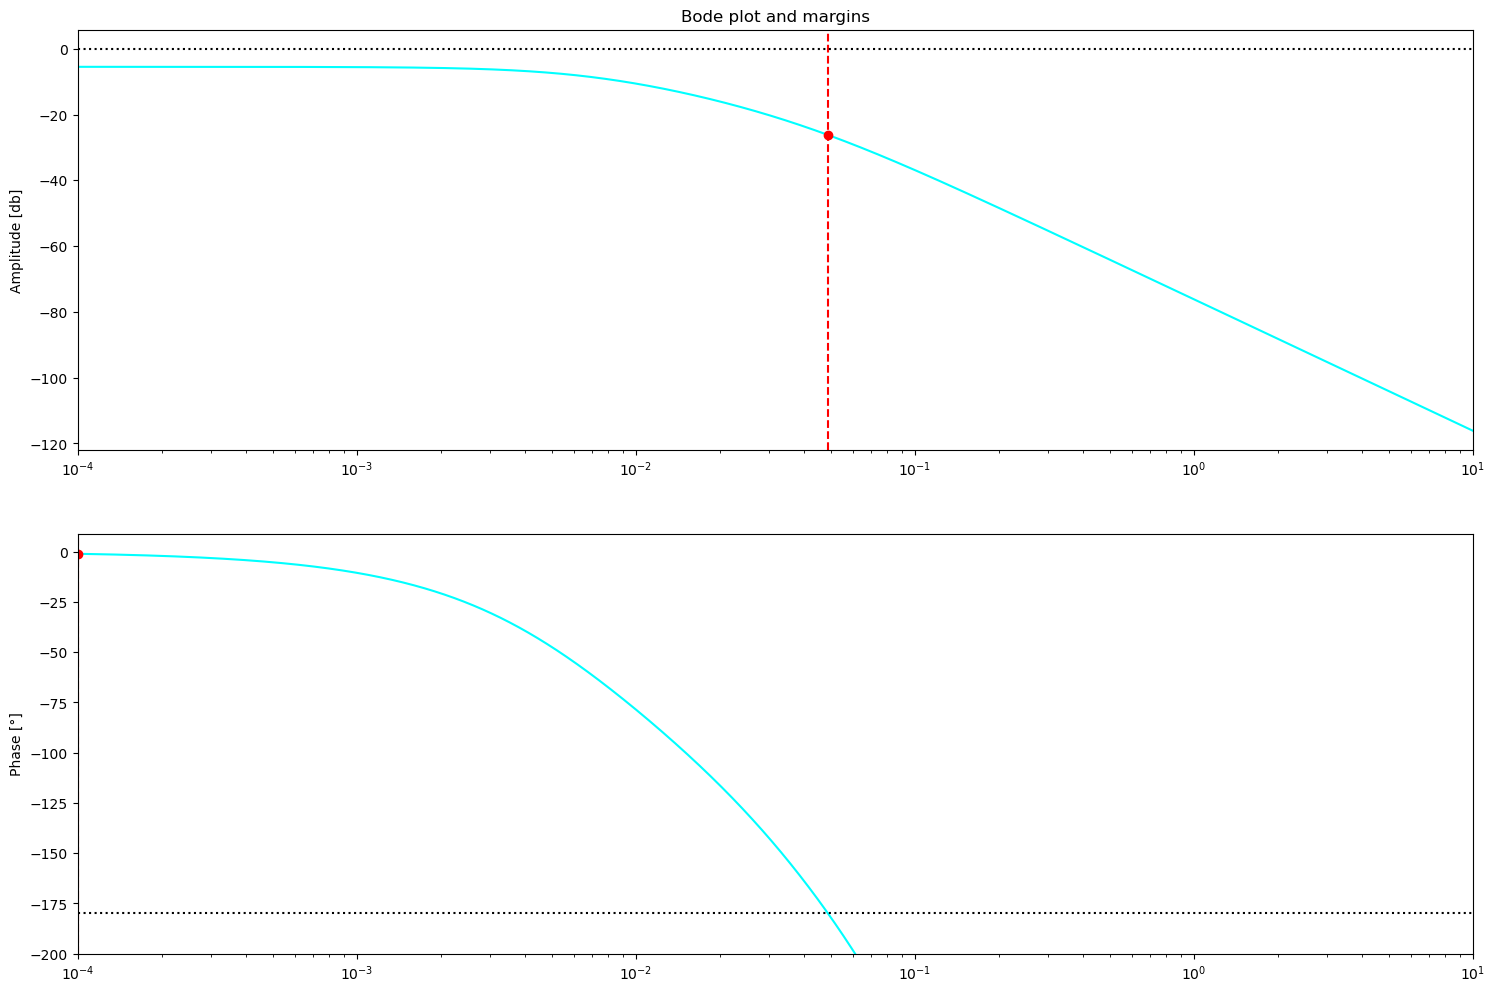

In [73]:
GM, PM =MARGIN(PS,omega)
print(f"Gain Margin (GM): {GM}, Phase Margin (PM): {PM}")
print(f"Gain Margin (GM) in dB: {20*np.log10(GM)} dB")